# Week 1–2: Data Cleaning & Exploratory Data

## Overview
Data scientists spend a significant portion of their time preparing data. Transform raw datasets into structured, analysis-ready formats while uncovering initial patterns and trends.
## Objective
To prepare datasets for modeling by:
- Cleaning and structuring raw data
- Identifying patterns, distributions, and relationships
- Generating insights to guide modeling decisions
## Task Breakdown
- Load datasets using Python (Pandas)
- Handle missing values and duplicates
- Perform univariate and bivariate analysis
- Visualize distributions and correlations
- Identify important features
## Tools
Python (Pandas, NumPy, Matplotlib, Seaborn)
## Datasets
Titanic Dataset `https://www.kaggle.com/datasets/yasserh/titanic-dataset`

## IMPORT MY NECESSARY DEPENDENCIES


In [100]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score,f1_score, roc_auc_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import joblib

# LOAD THE DATASET

In [2]:
Titanic = pd.read_csv("C:/Users/User PC/Downloads/AnalystLab_Africa_Internship/Titanic-Dataset.csv")

## DATA OVERVIEW
- `.head` returns the first five rows of the dataset
- `.tail` returns the last five rows of the dataset
- `.info` gives us every necessary information about the dataset
- `.shape` returns the number of rows and columns
- `.columns` returns all the columns in the dataset
- `.describe` gives a statistical moverview of the dataset
- `.dtypes` returns the datatypes for each columns

In [3]:
Titanic.head() #returns the first five rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
Titanic.tail() #returns the last 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
Titanic.info() #displays every necessary infotmation about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
Titanic.shape #returns the no of rows and columns

(891, 12)

In [7]:
Titanic.describe() # a statisticxal overview of the datset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
Titanic.dtypes #returns the data types for each

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## DATA CLEANING


In [9]:
Titanic.isnull().sum() # checks for missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
Titanic.isnull().sum() / len(Titanic) * 100 # percentage of missing values

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [11]:
Titanic.duplicated().sum() # checks for duplicated value

# no duplicated sum or value in the dataset

0

In [12]:
# handling missing values
Titanic["Age"].fillna(Titanic["Age"].median(), inplace = True)

In [13]:
Titanic["Embarked"].fillna(Titanic["Embarked"].mode()[0], inplace = True)

In [14]:
Titanic.drop("Cabin", axis = 1, inplace = True)

In [15]:
Titanic.isnull().sum() # checks for missing values after hamdling missing values

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## UNIVARIATE ANALYSIS
- Looks at one variable at a time

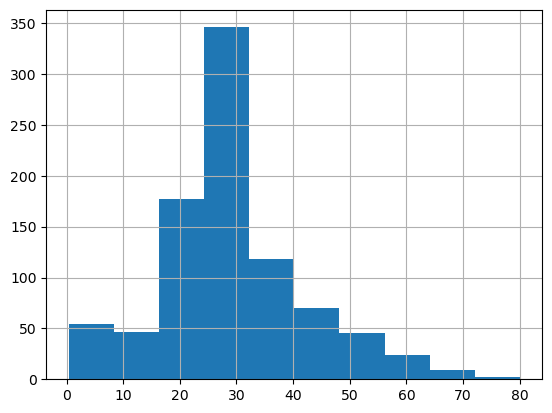

In [16]:
Titanic["Age"].hist();

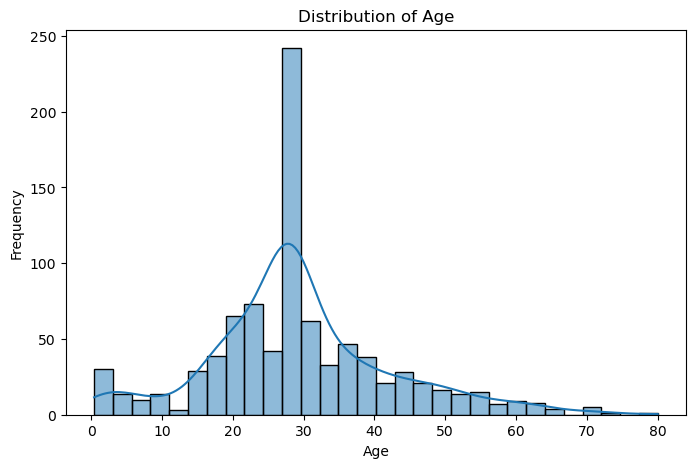

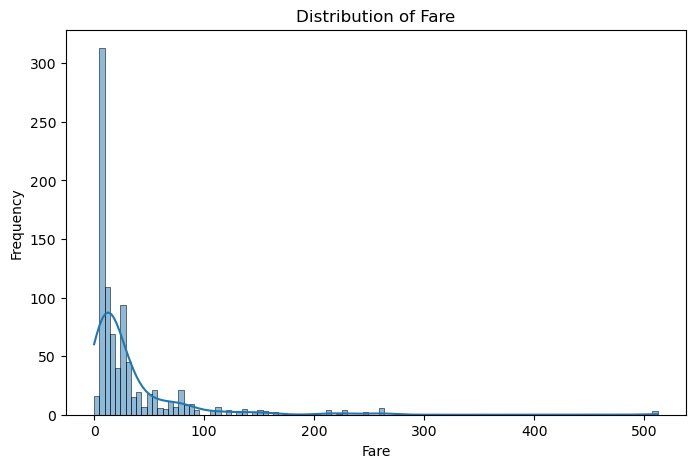

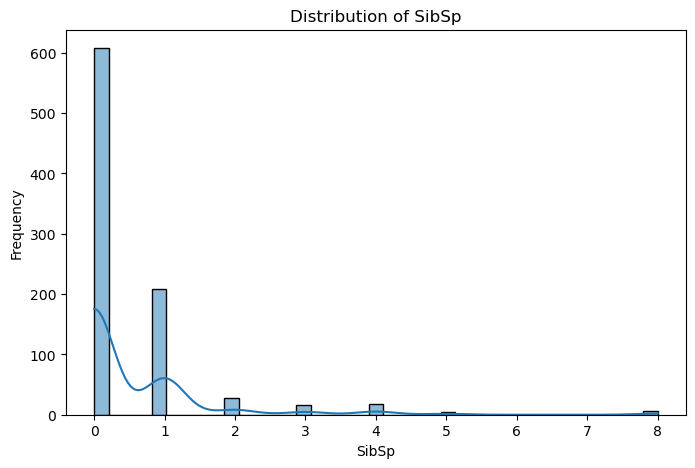

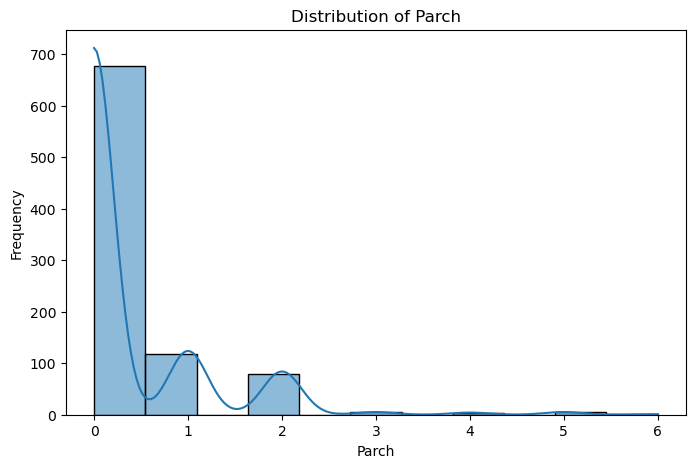

In [17]:
# Univariate Analysis of Numerical Variables

for col in ["Age", "Fare", "SibSp", "Parch"]:

    plt.figure(figsize=(8,5))

    sns.histplot(Titanic[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

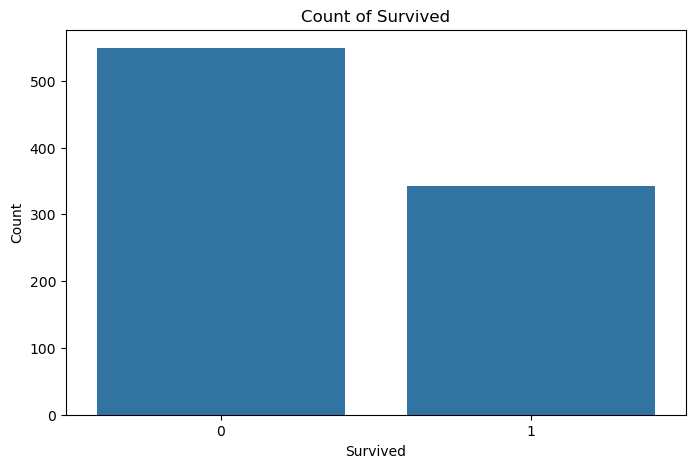

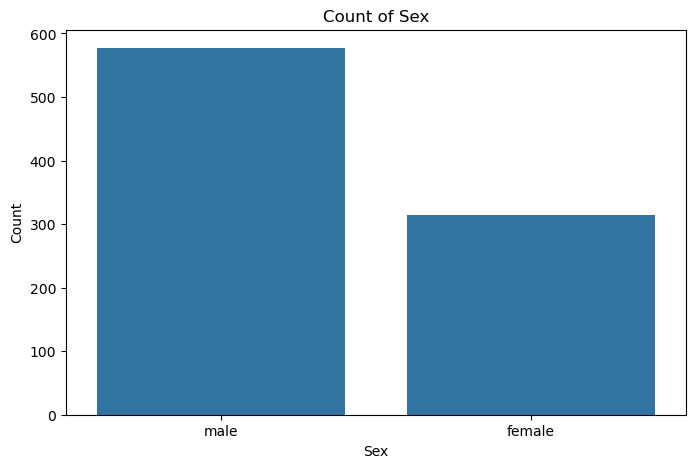

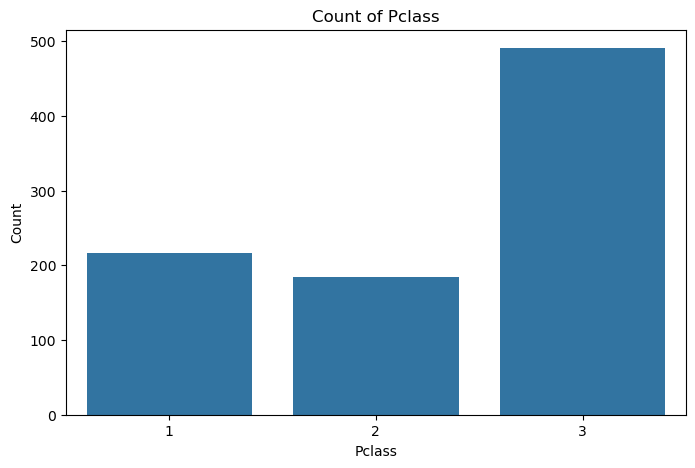

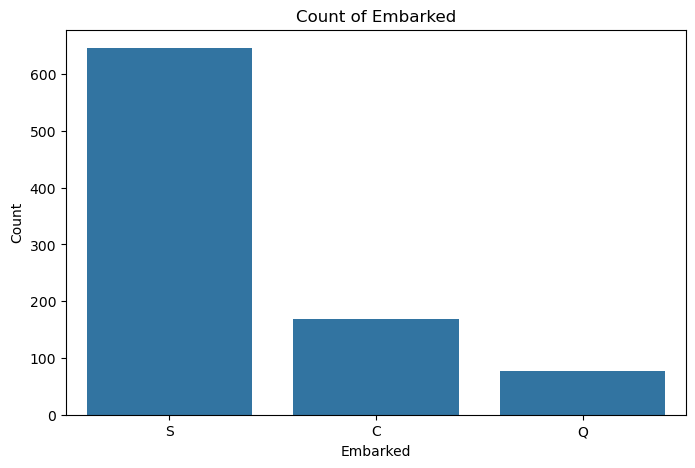

In [18]:
# Univariate Analysis for Categorical Columns
for col in ["Survived", "Sex", "Pclass", "Embarked"]:

    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=Titanic)

    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count");

## BIVARIATE ANALYSIS
- Compares two variables

In [19]:
# Bivariate analysis; Categorical vs Survived (Sex, Pclass, Embarked, SibSp, Parch)

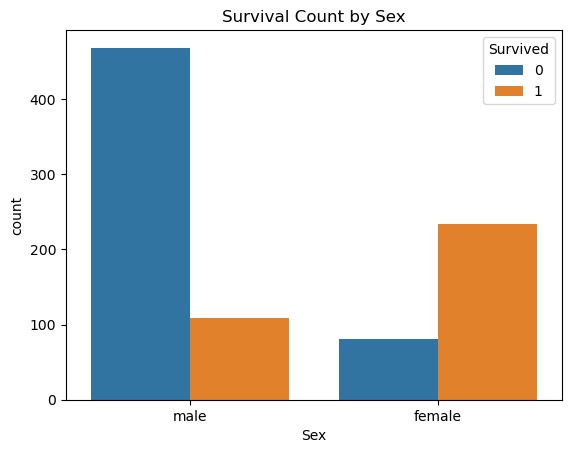

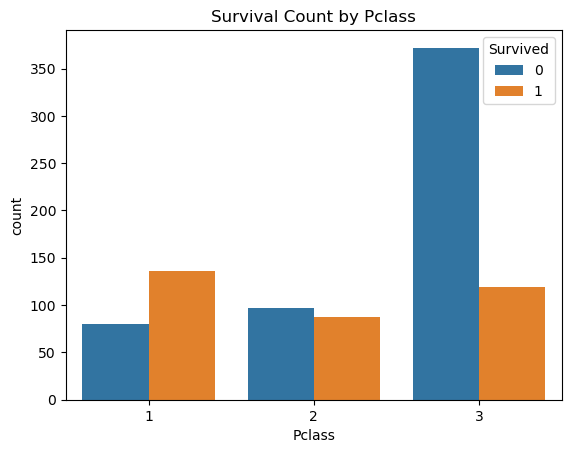

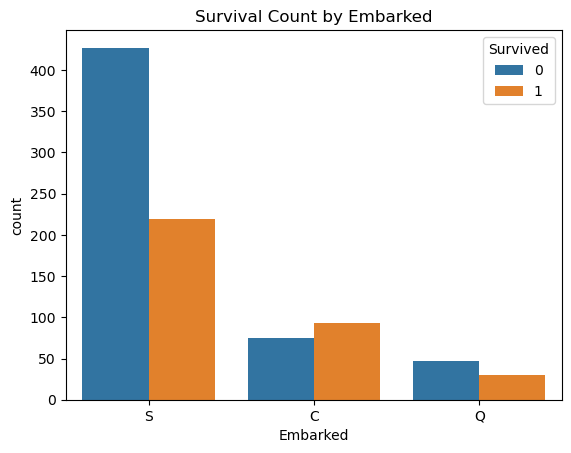

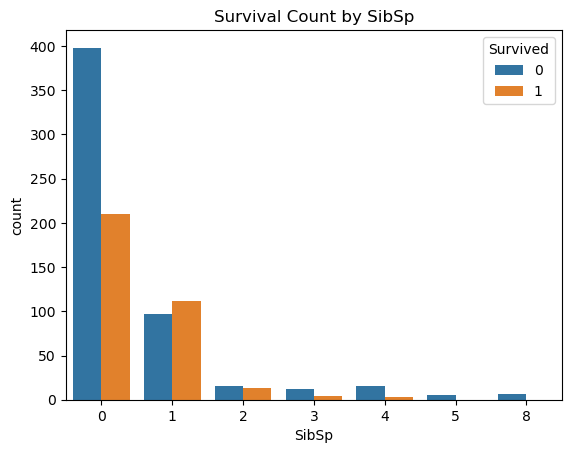

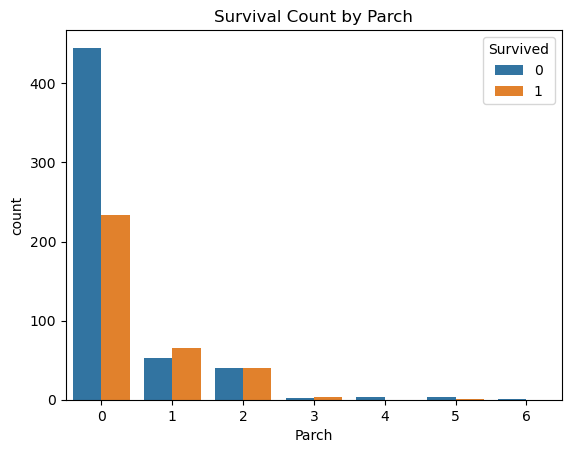

In [20]:
for col in ["Sex", "Pclass", "Embarked", "SibSp", "Parch"]:
    sns.countplot(x=col, hue = "Survived", data=Titanic)
    plt.title(f'Survival Count by {col}')
    plt.show()

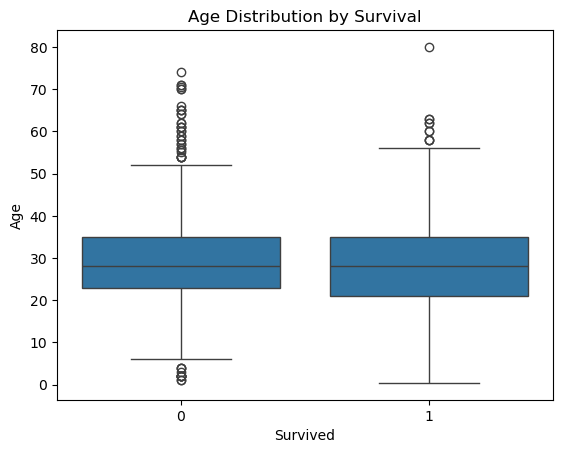

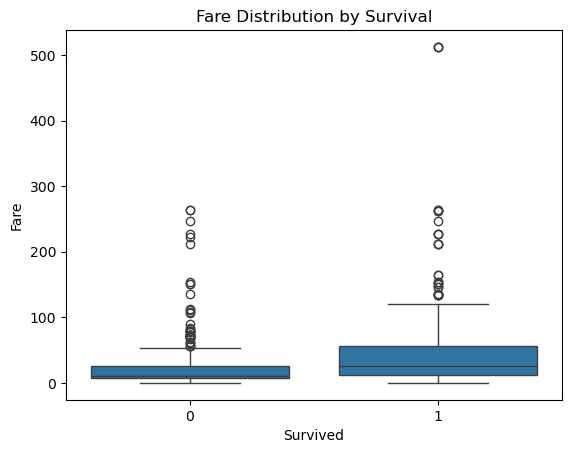

In [21]:
# Bivariate — Numerical vs Survived (Age, Fare)
for col in ['Age', 'Fare']:
    sns.boxplot(x='Survived', y=col, data=Titanic)
    plt.title(f'{col} Distribution by Survival')
    plt.show()

## CORRELATION HEATMAP

In [22]:
# Excludes non numeric columns

num_cols = Titanic.select_dtypes(include=["Float64", "int64"])

# Calculate the correction matrix
corr_matrix = num_cols.corr()
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


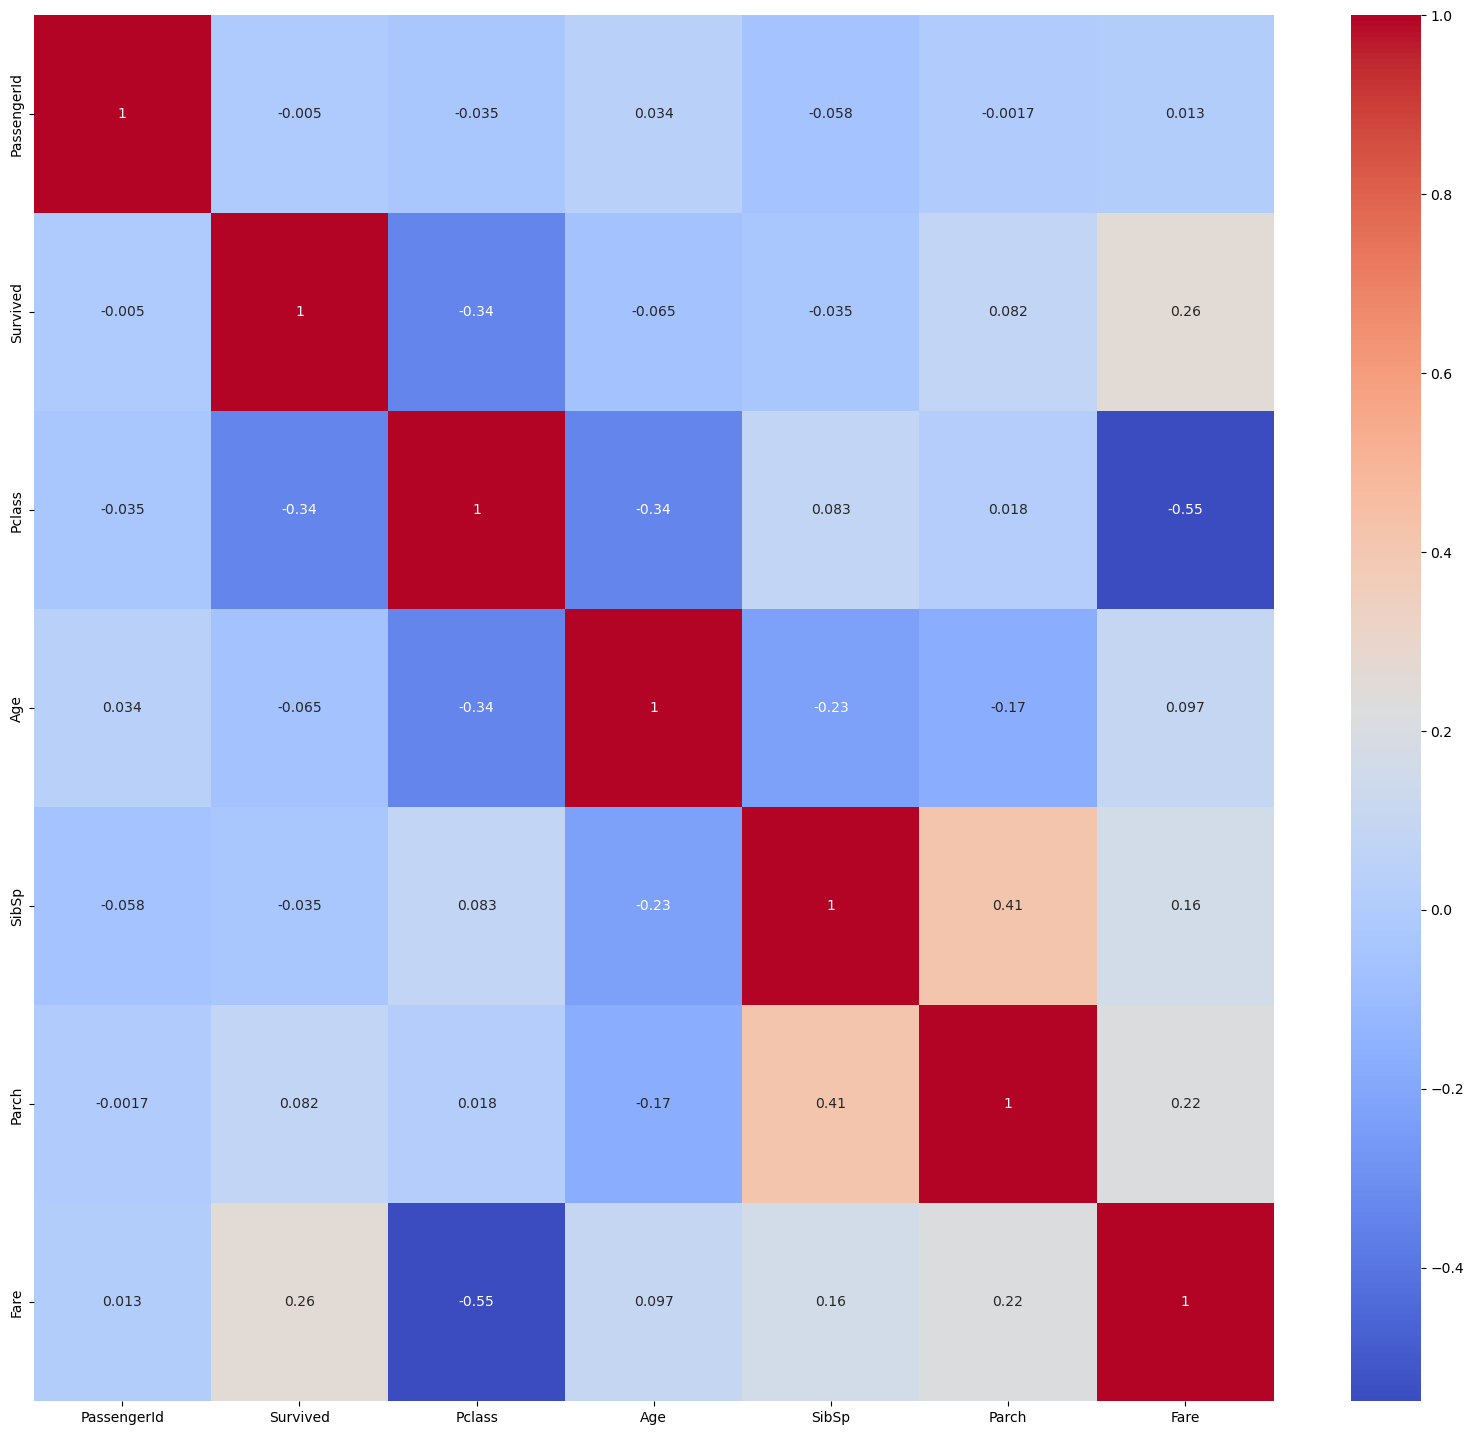

In [23]:
#Correlation Heatmap
plt.figure(figsize=(20,18))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.show()

In [24]:
# Feature Importance Analysis - Titanic

num_cols_titanic = ['Age', 'Fare', 'SibSp', 'Parch']

# Correlation with Survived
correlation_with_survived = Titanic[num_cols_titanic + ['Survived']].corr()['Survived'].sort_values(ascending=False)
print("Feature Correlation with Survival:")
print(correlation_with_survived)

# Categorical Features - Survival Rate by Category
cat_cols_titanic = ['Sex', 'Pclass', 'Embarked']

for col in cat_cols_titanic:
    print(f"\nSurvival rate by {col}:")
    print(Titanic.groupby(col)['Survived'].mean())

Feature Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Name: Survived, dtype: float64

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


## FEATURE IMPORTANCE
Feature Importance (ranked by strength of signal with Survived):

- Sex (correlation: -0.54 with Pclass, but visually clear in countplot — far more women survived than men)
- Pclass (correlation: -0.338 with Survived — 1st class had much higher survival than 3rd class)
- Fare (correlation: 0.257 with Survived — higher fares correlate with survival, likely because wealthier = higher class)
- Age (correlation: -0.065 with Survived — some effect, children/younger passengers had slightly better odds)
- Embarked, SibSp, Parch (weak signals — minimal visual difference between survived/didn't survive groups)


## Insight Summary

- Gender was the strongest predictor: Women had ~74% survival rate, men ~19%. The "women and children first" protocol clearly held.
- Class mattered significantly: 1st class passengers survived at ~62%, 3rd class at ~24%. Wealth/access to lifeboats was determinative.
- Fare correlated with survival: Higher ticket prices = higher survival (overlaps with class effect).
- Age had a minor effect: Children survived at slightly higher rates, but less dramatic than gender/class.
- Port of embarkation and family size had minimal impact on survival likelihood.

# WEEK 3 : STATISTICS AND PROBABILITY

## Objective
* To understand statistical concepts used in data science.
## Task Breakdown
- Descriptive statistics (mean, variance, std dev)
- Probability distributions
- Hypothesis testing
- Correlation vs causation

# Titanic Dataset - Descriptive Statistics Analysis

## Overview
- **Total Passengers:** 891
- **Overall Survival Rate:** 38.4%
- **Mean Age:** 29.4 years (std: 13.0)
- **Mean Fare:** $32.20 (std: $49.7, right-skewed)

## Key Findings

### 1. Gender was the Strongest Predictor of Survival
- Female survival rate: **74.2%**
- Male survival rate: **18.9%**
- **Insight:** Women were prioritized in evacuation ("women and children first")

### 2. Passenger Class Significantly Affected Survival
- Class 1: **63.0%** survival
- Class 2: **47.3%** survival
- Class 3: **24.2%** survival
- **Insight:** Wealthier passengers had better access to lifeboats

### 3. Gender + Class Interaction
| Sex | Class 1 | Class 2 | Class 3 |
|-----|---------|---------|---------|
| Female | 96.8% | 92.1% | 50.0% |
| Male | 36.9% | 15.7% | 13.5% |

**Critical Finding:** A 3rd-class woman (50%) had better odds than a 1st-class man (36.9%). **Gender overrode wealth.**

### 4. Fare Distribution
- Highly right-skewed: most passengers paid $0-50, few paid $300+
- Class 1 median: approximately $60-80
  
- Class 3 median: approximately $15-20

### 5. Correlation with Survival
- Fare: 0.26 (weak positive)
- Age: -0.06 (very weak negative)
- SibSp: -0.04 (negligible)
- Parch: 0.08 (negligible)

## Conclusion
Evacuation protocol prioritized **gender first, then class.** Wealth helped, but being a woman was the strongest advantage on the Titanic.

In [25]:
Titanic.describe() #statistical overview of the dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
Titanic["Age"].mean()

29.36158249158249

In [27]:
Titanic["Fare"].mean()

32.204207968574636

In [28]:
Titanic["Age"].median()

28.0

In [29]:
Titanic["Age"].var()

169.51249827942328

In [30]:
Titanic["Fare"].var()

2469.436845743117

In [31]:
Titanic["Age"].std()

13.019696550973194

In [32]:
Titanic["Fare"].std()

49.693428597180905

In [33]:
Titanic.groupby(["Age"])['Survived'].mean()

Age
0.42     1.0
0.67     1.0
0.75     1.0
0.83     1.0
0.92     1.0
        ... 
70.00    0.0
70.50    0.0
71.00    0.0
74.00    0.0
80.00    1.0
Name: Survived, Length: 88, dtype: float64

In [34]:
Titanic.groupby(["Sex"])['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [35]:
Titanic.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [36]:
Titanic.groupby(['Sex', 'Pclass'])['Survived'].mean() #comparing survival rate by class and sex

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [37]:
Titanic["Age_Bin"] = pd.cut(Titanic["Age"], bins=[0, 10, 20, 30, 40, 50, 80])
Titanic.groupby("Age_Bin")["Survived"].mean()

#Create age bins (groups) to make age more meaningful
# Instead of 88 individual ages, group them into age ranges

Age_Bin
(0, 10]     0.593750
(10, 20]    0.382609
(20, 30]    0.334152
(30, 40]    0.445161
(40, 50]    0.383721
(50, 80]    0.343750
Name: Survived, dtype: float64

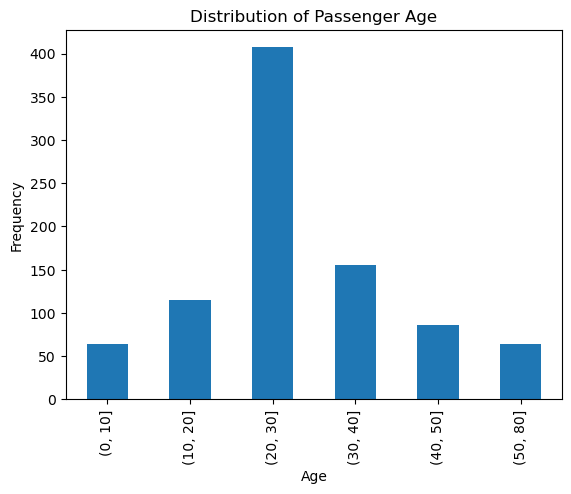

In [38]:
# Bar chart showing age distribution by age groups
# Since Age_Bin is categorical (intervals), bar chart works better than histogram
age_counts = Titanic["Age_Bin"].value_counts().sort_index()
age_counts.plot(kind="bar")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

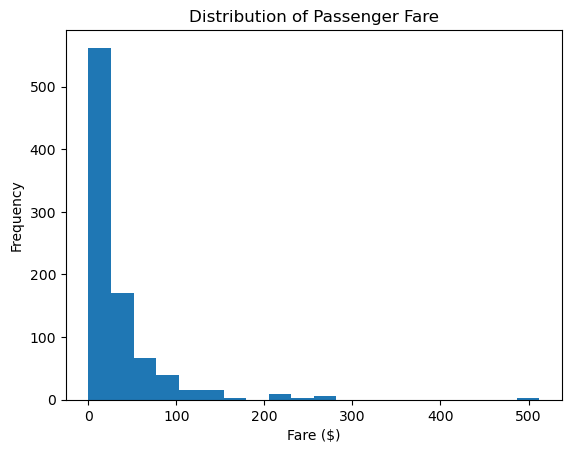

In [39]:
# Histogram showing fare distribution
# Fares are skewed—most people pay little, few pay a lot
plt.hist(Titanic["Fare"], bins=20)
plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare ($)")
plt.ylabel("Frequency")
plt.show()

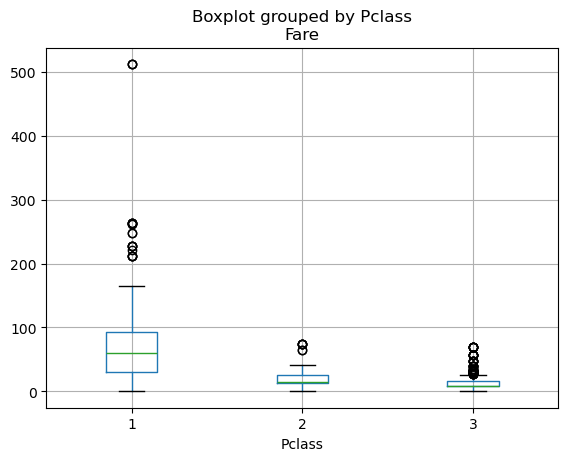

In [40]:
#Box plots showing fare by pclass
Titanic.boxplot(column="Fare", by="Pclass")
plt.show()

In [41]:
# Correlation Analysis
# Feature Importance Analysis - Titanic

num_cols_titanic = ['Age', 'Fare', 'SibSp', 'Parch']

# Correlation with Survived
correlation_with_survived = Titanic[num_cols_titanic + ['Survived']].corr()['Survived'].sort_values(ascending=False)
print("Feature Correlation with Survival:")
print(correlation_with_survived)

# Categorical Features - Survival Rate by Category
cat_cols_titanic = ['Sex', 'Pclass', 'Embarked']

for col in cat_cols_titanic:
    print(f"\nSurvival rate by {col}:")
    print(Titanic.groupby(col)['Survived'].mean())

Feature Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Name: Survived, dtype: float64

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


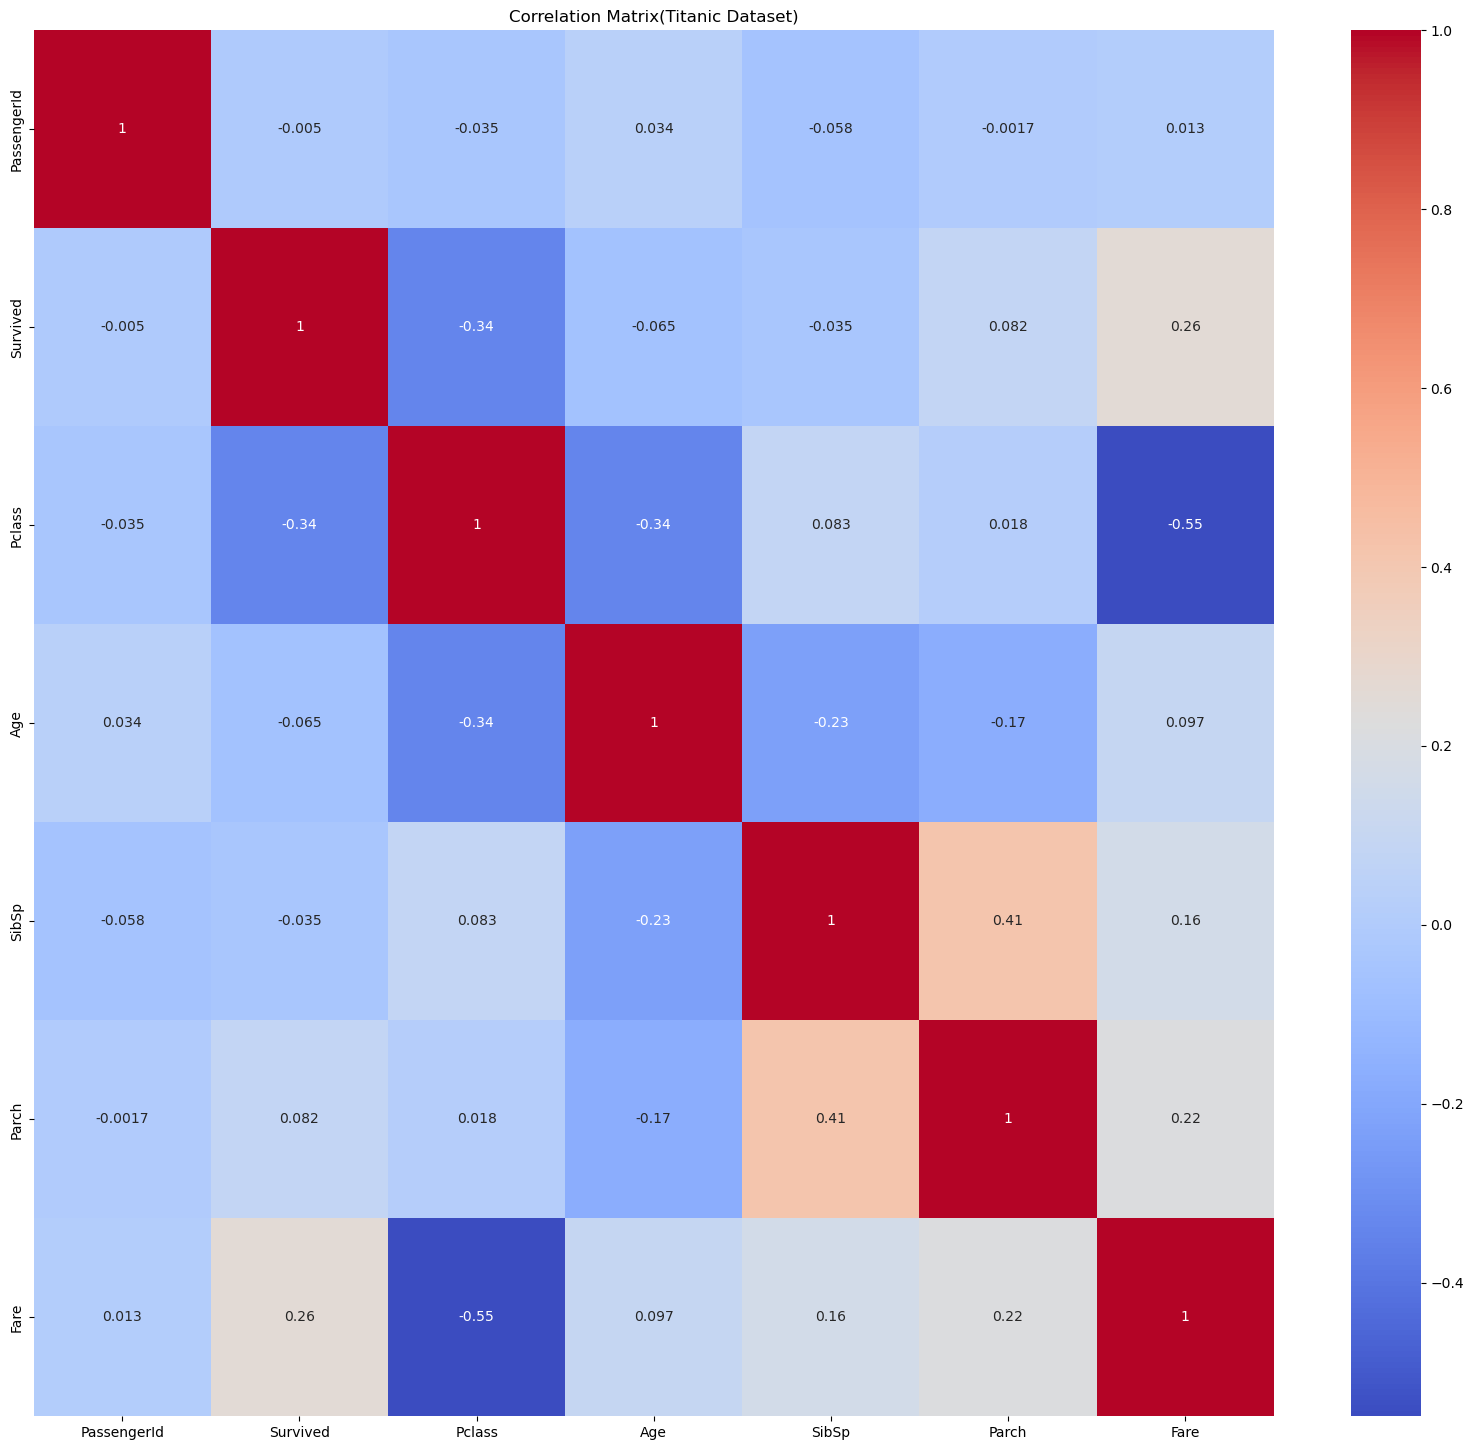

In [42]:
# Create a heatmap showing correlations between all numeric variables
# This shows which features are most related to survival
plt.figure(figsize=(20,18))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix(Titanic Dataset)")
plt.show()

# PROBABILITY DISTRIBUTION

# Probability Distributions - Titanic Dataset

## Overview
Analysis of how variables are distributed in the Titanic dataset. Tests whether continuous variables follow a normal (bell-curve) distribution.

## Method: Shapiro-Wilk Test
- **Null Hypothesis:** Data is normally distributed
- **p-value > 0.05** → Data IS normally distributed 
- **p-value < 0.05** → Data is NOT normally distributed 

## Results

### Continuous Variables

| Variable | Distribution | p-value | Normal |
|----------|--------------|---------|---------|
| Age | Peaks at 25-30, right tail | < 0.05 |  No |
| Fare | Highly right-skewed | < 0.05 | No |

### Key Findings

**Age Distribution:**
- Clusters around 25-30 years
- Long right tail (few elderly passengers)
- Shape: Approximately bimodal (two peaks)
- Not normally distributed

**Fare Distribution:**
- Highly right-skewed
- Most passengers paid $0-50
  
- Few paid $300+
- Not normally distributed

## Interpretation

Most real-world data is NOT perfectly normal. Both Age and Fare show practical skewness:
- Age: More young/middle-aged passengers than elderly
- Fare: Third-class passengers paid much less than first-class

This is expected in real datasets and affects which statistical tests we can use (e.g., non-parametric tests instead of t-tests).

## Conclusion

Titanic data shows **non-normal distributions**. Future hypothesis testing should account for this with appropriate statistical methods.

In [43]:
#probability a passenger survived
survived_probability = Titanic["Survived"].mean()
print(survived_probability)

0.3838383838383838


In [44]:
#probability of being female
(Titanic["Sex"]=="female").mean()


0.35241301907968575

In [45]:
#probability of first class
(Titanic["Pclass"]==1).mean()

0.24242424242424243

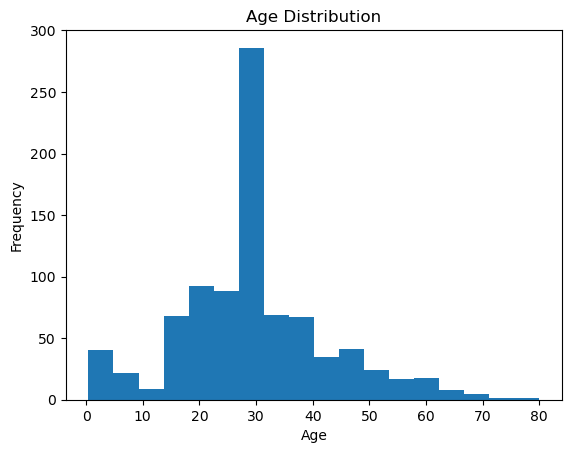

In [46]:
#probability distribution
plt.hist(Titanic["Age"], bins =18)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [47]:
# Test if Age is normally distributed

stat, p_value = stats.shapiro(Titanic["Age"].dropna())
print(f"Shapiro-Wilk Test for Age:")
print(f"p-value: {p_value}")

if p_value > 0.05:
    print("Age is Normally Distributed")
else:
    print("Age is Not Normally Distributed")

#Shapiro -Wilk test is a statistical test that checks if the data follows a normal distibution(bell curve)

Shapiro-Wilk Test for Age:
p-value: 4.651141686041376e-16
Age is Not Normally Distributed


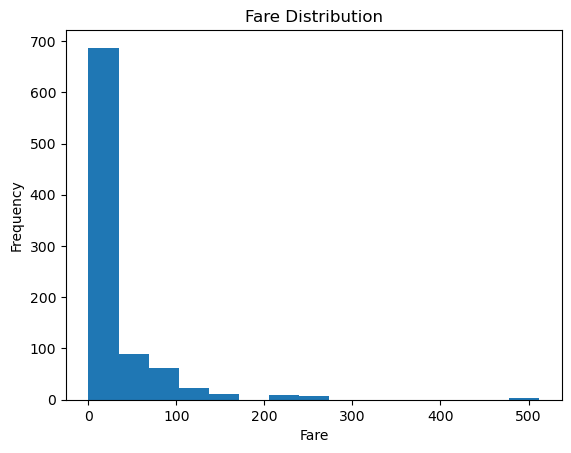

In [48]:
#histogram showing fare distribution
plt.hist(Titanic["Fare"], bins =15)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency");

In [49]:
# Test if Fare is normally distributed
stat, p_value =stats.shapiro(Titanic["Fare"].dropna())
print(f"Shapiro-Wilk Test for Fare:")
print(f"p-value: {p_value:}")

if p_value > 0.05:
    print("Fare is Normally Distributed")
else:
    print("Fare is not Normally Distributed")

Shapiro-Wilk Test for Fare:
p-value: 1.0840444395829658e-43
Fare is not Normally Distributed


# HYPOTHESIS TESTING

# Hypothesis Testing - Titanic Dataset

## Objective
Test whether key variables are significantly related to survival, or if differences are due to random chance.

## Test Results

### Test 1: Fare vs Survival (t-test)
**Hypothesis:**
- H0: Survivors and non-survivors paid the same fare
- H1: Survivors and non-survivors paid different fares

**Results:**
- t-statistic: 7.94
- p-value: 6.12e-15 (essentially 0)
- **Conclusion:**  **SIGNIFICANT** - Survivors paid significantly higher fares than non-survivors


### Test 2: Sex vs Survival (Chi-Square Test)
**Hypothesis:**
- H0: Sex and Survival are independent
- H1: Sex and Survival are related

**Results:**
- Chi-Square statistic: 260.72
- p-value: 1.20e-58 (essentially 0)
- Degrees of freedom: 1
- **Conclusion:**  **SIGNIFICANT** - Sex IS significantly related to Survival

### Test 3: Pclass vs Survival (Chi-Square Test)
**Hypothesis:**
- H0: Passenger class and Survival are independent
- H1: Passenger class and Survival are related

**Results:**
- Chi-Square statistic: 102.89
- p-value: 4.55e-23 (essentially 0)
- Degrees of freedom: 2
- **Conclusion:**  **SIGNIFICANT** - Passenger class IS significantly related to Survival

## Key Findings

All three variables show **highly significant relationships** with survival:
1. **Fare matters:** Survivors paid more (p < 0.001)
2. **Sex matters MOST:** Gender was the strongest predictor (p < 0.001)
3. **Class matters:** Higher class = higher survival (p < 0.001)

All p-values are extremely small (< 0.05), meaning these findings are NOT due to random chance. They are real, significant patterns in the data.

## Conclusion

The Titanic survival was determined by a combination of:
1. **Gender** (women prioritized in evacuation)
2. **Class** (wealthy had better access)
3. **Fare** (proxy for class and priority)

These relationships are statistically proven, not coincidence.

In [50]:
# does fare differs between survivors and non survivors

survived = Titanic[Titanic["Survived"]==1]["Fare"]
dead = Titanic[Titanic["Survived"]==0]["Fare"]

t,p = ttest_ind(survived, dead)

print(t,p)

7.939191660871055 6.120189341924198e-15


In [51]:

# Chi-Square Test 1: Sex vs Survival
# Create a contingency table (cross-tabulation)
contingency_sex = pd.crosstab(Titanic['Sex'], Titanic['Survived'])
print("Contingency Table: Sex vs Survival")
print(contingency_sex)
print()

# Run Chi-Square test
chi2_sex, p_sex, dof_sex, expected_sex = chi2_contingency(contingency_sex)
print(f"Chi-Square Test: Sex vs Survival")
print(f"Chi-Square statistic: {chi2_sex}")
print(f"p-value: {p_sex}")
print(f"Degrees of freedom: {dof_sex}")

if p_sex < 0.05:
    print("Result: Sex IS significantly related to Survival")
else:
    print("Result: Sex is NOT significantly related to Survival")
print()


Contingency Table: Sex vs Survival
Survived    0    1
Sex               
female     81  233
male      468  109

Chi-Square Test: Sex vs Survival
Chi-Square statistic: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
Result: Sex IS significantly related to Survival



In [52]:

# Chi-Square Test 2: Pclass vs Survival
# Create a contingency table
contingency_pclass = pd.crosstab(Titanic['Pclass'], Titanic['Survived'])
print("Contingency Table: Pclass vs Survival")
print(contingency_pclass)
print()

# Run Chi-Square test
chi2_pclass, p_pclass, dof_pclass, expected_pclass = chi2_contingency(contingency_pclass)
print(f"Chi-Square Test: Pclass vs Survival")
print(f"Chi-Square statistic: {chi2_pclass}")
print(f"p-value: {p_pclass}")
print(f"Degrees of freedom: {dof_pclass}")

if p_pclass < 0.05:
    print("Result: Pclass IS significantly related to Survival")
else:
    print("Result: Pclass is NOT significantly related to Survival")

Contingency Table: Pclass vs Survival
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Chi-Square Test: Pclass vs Survival
Chi-Square statistic: 102.88898875696056
p-value: 4.549251711298793e-23
Degrees of freedom: 2
Result: Pclass IS significantly related to Survival


# CORRELATION VS CAUSATION

# Correlation vs Causation - Titanic Dataset

## Overview
Distinguishing between **correlation** (variables move together) and **causation** (one variable causes changes in another).

## Analysis by Variable

### 1. Fare vs Survival

**Correlation:** Yes (r = 0.257, weak positive)
- Higher fare means  slightly higher survival rate
- Passengers who paid more survived more often

**Is it Causation?** NO 

**Why?** Pclass confounds the relationship
- Class 1 passengers paid $84 average
- Class 2 passengers paid $21 average
- Class 3 passengers paid $14 average
- Higher class = higher fare AND higher survival

**Visualization shows:** Class 1 (blue) paid $100-500 and survived more. Class 3 (green) paid $0-50 and died more. The classes are completely separated.

**Real Cause:** **Pclass (passenger class/wealth), not fare itself**
- Being wealthy means  better access to lifeboats which means  survival
- Fare is just a proxy for wealth/class
- A poor Class 3 passenger couldn't have bought survival, even with more money


### 2. Sex vs Survival

**Correlation:** Yes, very strong
- Female: 74.2% survival
- Male: 18.9% survival

**Is it Causation?** PARTIALLY YES 

**Why?** The evacuation protocol was "women and children first"
- Gender directly influenced who boarded lifeboats
- Women were prioritized by crew
- This is a direct causal mechanism

**Evidence:** Even Class 3 women (50% survival) outsurvived Class 1 men (36.9% survival)
- This shows gender > wealth in the evacuation priority

**Real Cause:** **Evacuation protocol prioritized women**
- Being female caused higher chance of lifeboat assignment
- This is true causation, not just correlation



### 3. Pclass vs Survival

**Correlation:** Yes, very strong
- Class 1: 63.0% survival
- Class 2: 47.3% survival
- Class 3: 24.2% survival

**Is it Causation?** YES 

**Why?** Multiple causal mechanisms:
1. **Physical access:** First-class cabins were closer to lifeboats
2. **Information:** First-class passengers were notified earlier
3. **Priority:** Crew prioritized first-class passengers
4. **Language/Status:** First-class passengers could communicate with crew more easily

**Real Cause:** **Socioeconomic status and access** determined survival chances


## Key Insight

**Causation hierarchy on the Titanic:**
1. **Gender** was the strongest causal factor (women first protocol)
2. **Class** was the second causal factor (access and priority)
3. **Fare** was NOT causal—it was a symptom of being wealthy (Pclass)

The evacuation prioritized **gender > class > wealth**, with gender being the dominant factor in determining who survived.

In [53]:
# calculate correlations with survived
print(f"Correlation with Survival:")
print(Titanic[["Fare", "Survived"]].corr())
print()

Correlation with Survival:
              Fare  Survived
Fare      1.000000  0.257307
Survived  0.257307  1.000000



In [54]:
# checks if pclass confounds Fare - Survival relationship
print("Does Pclass affects Survival:")
print(Titanic.groupby("Pclass")["Fare"].mean())
print()

Does Pclass affects Survival:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64



In [55]:
# Check survival correlation
print("Survival by Sex:")
print(Titanic.groupby("Sex")["Survived"].mean())

Survival by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [56]:
#checks if class affects sex-survival relationship

print("Survival by Sex and Pclass")
print(Titanic.groupby(["Sex", "Pclass"])["Survived"].mean())

Survival by Sex and Pclass
Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


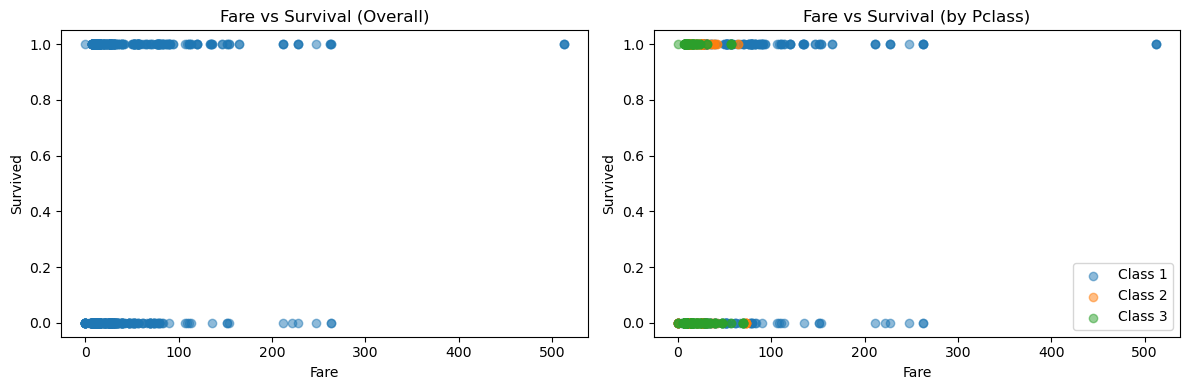

In [57]:

# Visualize: Does Pclass confound Fare-Survival?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fare vs Survival (overall)
axes[0].scatter(Titanic['Fare'], Titanic['Survived'], alpha=0.5)
axes[0].set_title("Fare vs Survival (Overall)")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Survived")

# Fare vs Survival (colored by Pclass)
for pclass in [1, 2, 3]:
    data = Titanic[Titanic['Pclass'] == pclass]
    axes[1].scatter(data['Fare'], data['Survived'], label=f'Class {pclass}', alpha=0.5)
axes[1].set_title("Fare vs Survival (by Pclass)")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Survived")
axes[1].legend()

plt.tight_layout()
plt.show()

# Week 4: Supervised Learning
## Objective
- Predict passenger survival.
## Steps:
- Load the dataset
- Clean/preprocess data
- Encode categorical variables if needed
- Train a Logistic Regression model
- Make predictions
- Evaluate the model using Accuracy Score


# Titanic Dataset - Logistic Regression Model

## Dataset
- **Name:** Titanic Dataset
- **Total Samples:** 891 passengers
- **Target Variable:** Survived (1 = Survived, 0 = Did not survive)
- **Features Used:** Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

- Encoded categorical variables:
  - Sex: male/female → 0/1
  - Pclass: 1/2/3 (already numeric)
  - Embarked: S/C/Q → 0/1/2

## Model Training
- **Algorithm:** Logistic Regression
- **Train/Test Split:** 80/20 (test_size=0.2)
- **Random State:** 42

## Model Performance

**Overall Accuracy: 0.81 (81%)**

### Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0 (Did not survive) | 0.83 | 0.86 | 0.84 | 105 |
| 1 (Survived) | 0.79 | 0.74 | 0.76 | 74 |
| **Accuracy** | | | **0.81** | **179** |
| Macro Avg | 0.81 | 0.80 | 0.80 | 179 |
| Weighted Avg | 0.81 | 0.81 | 0.81 | 179 |

## Interpretation

- **Accuracy (81%):** The model correctly predicts survival 81% of the time on unseen data.
- **Precision (79-83%):** When the model predicts a class, it's correct 79-83% of the time.
- **Recall (74-86%):** The model catches 74-86% of actual survivors and non-survivors.
- **F1-Score (0.76-0.84):** Good balance between precision and recall for both classes.

## Key Insights

1. Model performs well overall (81% accuracy).
2. Better at identifying non-survivors (86% recall) than survivors (74% recall).
3. Strong precision for both classes indicates low false positives.
4. The model is balanced and reliable for both prediction classes.

## Challenges

- Class imbalance: More non-survivors (105) than survivors (74) in test set.
- Some survivors missed due to lower recall (74%) for survival class.

## Conclusion

The Logistic Regression model successfully predicts passenger survival on the Titanic dataset with 81% accuracy. The model is reliable for both classes and can be used for survival prediction based on passenger demographics.

In [58]:
Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,"(20, 30]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,"(30, 40]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,"(20, 30]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,"(30, 40]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,"(30, 40]"


In [59]:
# Data preprocessing and Feature Selection

le = LabelEncoder() #encoding categorical column using label encoder

In [60]:
cols = ["Sex", "Pclass", "Embarked"]
for col in cols:
    Titanic[col] = le.fit_transform(Titanic[col])
# Male is 1, female is 0
#Pclass 3= 2, 2= 1, 1= 0
#embarked c =2, q=1 and s=0

In [61]:
Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Bin
0,1,0,2,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2,"(20, 30]"
1,2,1,0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0,"(30, 40]"
2,3,1,2,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2,"(20, 30]"
3,4,1,0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,"(30, 40]"
4,5,0,2,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2,"(30, 40]"


In [62]:
X = Titanic.drop(columns = ["PassengerId", "Survived", "Name", "Ticket", "Age_Bin"]) #input or features
y = Titanic["Survived"] #target

In [63]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,2,1,22.0,1,0,7.2500,2
1,0,0,38.0,1,0,71.2833,0
2,2,0,26.0,0,0,7.9250,2
3,0,0,35.0,1,0,53.1000,2
4,2,1,35.0,0,0,8.0500,2


In [64]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [65]:
model = LogisticRegression()

In [66]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
model.fit(X_train, y_train) #fitting the trainset into the model

LogisticRegression()

In [67]:
# make predictions 
prediction = model.predict(X_test)
prediction

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [68]:
# calculating the accuracy of my model
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy :", accuracy)
print(f"\nClassification Report for Test Set:\n", classification_report(y_test, prediction))

Accuracy : 0.8100558659217877

Classification Report for Test Set:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [69]:
acc = accuracy_score(y_test, prediction)
print(f"ACCURACY OF THIS MODEL IS:", acc)

precision = precision_score(y_test, prediction)
print(f"PRECISON IS:", precision)

recall = recall_score(y_test,prediction)
print(f"RECALL IS : {recall}")

f1 = f1_score(y_test,prediction)
print(f"F1 SCORE IS : {f1}")

roc = roc_auc_score(y_test,prediction)
print(f"ROC - AUC SCORE IS : {roc}")

ACCURACY OF THIS MODEL IS: 0.8100558659217877
PRECISON IS: 0.7857142857142857
RECALL IS : 0.7432432432432432
F1 SCORE IS : 0.7638888888888888
ROC - AUC SCORE IS : 0.8001930501930502


# Week 5: Advanced Machine Learning
## Overview
- explore advanced machine learning algorithms and learn how to improve model performance through model selection and hyperparameter tuning.
- The goal is to build multiple machine learning models, compare their performance, and identify the best-performing model for my chosen dataset.
## Objective
- To improve predictive performance using advanced machine learning algorithms and optimization techniques.


### Decision Tree Classifier
- Accuracy: 0.7821
- Precision: 0.7215
- Recall: 0.7703
- F1-Score: 0.7450
- ROC-AUC: 0.7803



In [70]:
model = DecisionTreeClassifier()

In [71]:
model.fit(X_train,y_train) #fitting the train set into the model

DecisionTreeClassifier()

In [72]:
prediction = model.predict(X_test) #make predictions
prediction

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1], dtype=int64)

In [73]:
acc = accuracy_score(y_test, prediction)
print(f"ACCURACY OF THIS MODEL IS:", acc)

precision = precision_score(y_test, prediction)
print(f"PRECISON IS:", precision)

recall = recall_score(y_test,prediction)
print(f"RECALL IS : {recall}")

f1 = f1_score(y_test,prediction)
print(f"F1 SCORE IS : {f1}")

roc = roc_auc_score(y_test,prediction)
print(f"ROC - AUC SCORE IS : {roc}")

ACCURACY OF THIS MODEL IS: 0.776536312849162
PRECISON IS: 0.7125
RECALL IS : 0.7702702702702703
F1 SCORE IS : 0.7402597402597403
ROC - AUC SCORE IS : 0.7756113256113256


### Random Forest Classifier
- Accuracy: 0.8044
- Precision: 0.7671
- Recall: 0.7567
- F1-Score: 0.7619
- ROC-AUC: 0.7942


In [74]:
forest = RandomForestClassifier()

In [75]:
forest.fit(X_train, y_train) #fit the train set into the model

RandomForestClassifier()

In [76]:
prediction = forest.predict(X_test) #make predictions
prediction

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [77]:
acc = accuracy_score(y_test, prediction)
print(f"ACCURACY OF THIS MODEL IS:", acc)

precision = precision_score(y_test, prediction)
print(f"PRECISON IS:", precision)

recall = recall_score(y_test,prediction)
print(f"RECALL IS : {recall}")

f1 = f1_score(y_test,prediction)
print(f"F1 SCORE IS : {f1}")

roc = roc_auc_score(y_test,prediction)
print(f"ROC - AUC SCORE IS : {roc}")

ACCURACY OF THIS MODEL IS: 0.8212290502793296
PRECISON IS: 0.7916666666666666
RECALL IS : 0.7702702702702703
F1 SCORE IS : 0.7808219178082192
ROC - AUC SCORE IS : 0.8137065637065637


### Gradient Boosting Classifier
- Accuracy: 0.8100
- Precision: 0.8125
- Recall: 0.7027
- F1-Score: 0.7536
- ROC-AUC: 0.7940

In [78]:
gradient = GradientBoostingClassifier()

In [79]:
gradient.fit(X_train, y_train)

GradientBoostingClassifier()

In [80]:
prediction = gradient.predict(X_test) #make predictions
prediction

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [81]:
acc = accuracy_score(y_test, prediction)
print(f"ACCURACY OF THIS MODEL IS:", acc)

precision = precision_score(y_test, prediction)
print(f"PRECISON IS:", precision)

recall = recall_score(y_test,prediction)
print(f"RECALL IS : {recall}")

f1 = f1_score(y_test,prediction)
print(f"F1 SCORE IS : {f1}")

roc = roc_auc_score(y_test,prediction)
print(f"ROC - AUC SCORE IS : {roc}")

ACCURACY OF THIS MODEL IS: 0.8100558659217877
PRECISON IS: 0.8125
RECALL IS : 0.7027027027027027
F1 SCORE IS : 0.7536231884057971
ROC - AUC SCORE IS : 0.7942084942084942


# HYPER PARAMETER TUNING
- Since ill be improving one of my model, ill be doing hyper parameter tuning for Random Forest Classifier


### Random Forest Classifier - GridSearchCV
Hyperparameter tuning uses GridSearchCV to test multiple parameter combinations and find the best ones.

**Parameters Tested:**
- n_estimators: [50, 100, 200]
- max_depth: [5, 10, 15, 20]
- min_samples_split: [2, 5, 10]

**Best Parameters Found:**
- n_estimators: 100
- max_depth: 5
- min_samples_split: 2

**Tuned Model Performance:**
- Accuracy: 0.8156
- Precision: 0.8360
- Recall: 0.6891
- F1-Score: 0.7555
- ROC-AUC: 0.7969

In [82]:
# define parameter grid to test

param_grid = {
    "n_estimators" : [50, 100, 200],
    "max_depth" : [5, 10, 15, 20],
    "min_samples_split" : [2, 5, 10]

}

#create randomforest model
rf = RandomForestClassifier(random_state=42)

#GridSearchCV tests all combinations and find the best
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1)

#fit GridSearchCV(this trains multiple model)
grid_search.fit(X_train, y_train)

#Get best parameter and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best parameters: {best_params}")

#make predictions with tuned model
prediction = best_model.predict(X_test)

#calculate metrics
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
roc = roc_auc_score(y_test, prediction)
    
#print
print(f"ACCURACY: {accuracy}")
print(f"PRECISION: {precision}")
print(f"RECALL: {recall}")
print(f"F1-SCORE: {f1}")
print(f"ROC_AUC_SCORE: {roc}")

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
ACCURACY: 0.8156424581005587
PRECISION: 0.8360655737704918
RECALL: 0.6891891891891891
F1-SCORE: 0.7555555555555555
ROC_AUC_SCORE: 0.796975546975547


In [83]:
titanic_results = {
    'Baseline Logistic Regression': {'Accuracy': 0.8100, 'Precision': 0.7215, 'Recall': 0.7702, 'F1-Score': 0.7638, 'ROC-AUC': 0.8001},
    'Decision Tree': {'Accuracy': 0.7821, 'Precision': 0.7215, 'Recall': 0.7703, 'F1-Score': 0.7450, 'ROC-AUC': 0.7803},
    'Random Forest': {'Accuracy': 0.8044, 'Precision': 0.7671, 'Recall': 0.7567, 'F1-Score': 0.7619, 'ROC-AUC': 0.7942},
    'Gradient Boosting': {'Accuracy': 0.8100, 'Precision': 0.8125, 'Recall': 0.7027, 'F1-Score': 0.7536, 'ROC-AUC': 0.7940},
    'Tuned Model': {'Accuracy': 0.8156, 'Precision': 0.8360, 'Recall': 0.6891, 'F1-Score': 0.7555, 'ROC-AUC': 0.7969}
}

In [84]:
#store in result dictionary
titanic_results ["Tuned Model"] = {"Accuracy" : 0.8156, "Precision" : 0.8360, "Recall" : 0.6891, "F1-Score" : 0.7555, "ROC-AUC" : 0.7969}

# COMPARISON TABLE


**Best Model: Tuned Random Forest Classifier**

**Reasons:**
- Highest Accuracy: 0.8156 (correctly classifies 81.56% of passengers)
- Highest Precision: 0.8360 (most reliable positive predictions)
- Highest ROC-AUC: 0.7969 (excellent discrimination between classes)

The tuned model outperforms other classifiers by balancing accuracy and precision. While it has lower recall (0.6891), the high precision indicates fewer false positives—crucial for survival prediction accuracy.

In [85]:
# Extract values from titanic_results dictionary
results = pd.DataFrame({
    "Model": list(titanic_results.keys()),
    "Accuracy": [titanic_results[model]["Accuracy"] for model in titanic_results],
    "Precision": [titanic_results[model]["Precision"] for model in titanic_results],
    "Recall": [titanic_results[model]["Recall"] for model in titanic_results],
    "F1-Score": [titanic_results[model]["F1-Score"] for model in titanic_results],
    "ROC-AUC": [titanic_results[model]["ROC-AUC"] for model in titanic_results],
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.8100,0.7215,0.7702,0.7638,0.8001
1,Decision Tree,0.7821,0.7215,0.7703,0.7450,0.7803
2,Random Forest,0.8044,0.7671,0.7567,0.7619,0.7942
3,Gradient Boosting,0.8100,0.8125,0.7027,0.7536,0.7940
4,Tuned Model,0.8156,0.8360,0.6891,0.7555,0.7969


# VISUALIZATION



###  Top 10 Feature Importance - Tuned Random Forest Model
The bar chart shows which features are most critical for predicting Titanic survival:
- **Sex** (0.50) is the dominant predictor—gender was the strongest survival factor
- **Fare** (0.17) is second—ticket price indicates passenger class/status
- **Pclass** (0.15) is third—passenger class affected survival rates
- **Age** (0.10) is fourth—age influenced survival probability
- Features like Embarked, Parch, SibSp have minimal impact

This aligns with historical Titanic data: "women and children first" rescue priority explains Sex's dominance.

### Model Performance Comparison - Accuracy
Bar chart ranking all models by accuracy:
- **Baseline Logistic Regression**: 0.8100
- **Tuned Model**: 0.8156 (Best)
- **Gradient Boosting**: 0.8100
- **Random Forest**: 0.8044
- **Decision Tree**: 0.7821

The tuned model achieves the highest accuracy (81.56%), slightly outperforming baselines. All ensemble methods perform similarly, suggesting the dataset is well-suited for tree-based approaches.

###  Confusion Matrix - Tuned Random Forest
The heatmap shows prediction breakdown:
- **True Negatives (95)**: Correctly identified non-survivors
- **True Positives (51)**: Correctly identified survivors
- **False Positives (10)**: Wrongly predicted as survivors
- **False Negatives (23)**: Wrongly predicted as non-survivors

**Accuracy**: (95 + 51) / 179 = 81.56%
The model is more conservative—it correctly identifies non-survivors but misses some actual survivors (lower recall for survivors).

### ROC Curves Comparison
The ROC curves compare all models' ability to discriminate between survivors and non-survivors:
- **Random Forest**: AUC = 0.891 (Best—highest discrimination)
- **Decision Tree**: AUC = 0.890 (Nearly identical to Random Forest)
- **Tuned Random Forest**: AUC = 0.890 (Tuning maintained performance)
- **Gradient Boosting**: AUC = 0.881 (Slightly lower, still excellent)
- **Random Classifier**: AUC = 0.5 (Baseline—no predictive power)

All models perform well above the random baseline. Random Forest's slight edge (0.891) indicates the best balance between catching survivors and avoiding false alarms across all decision thresholds.

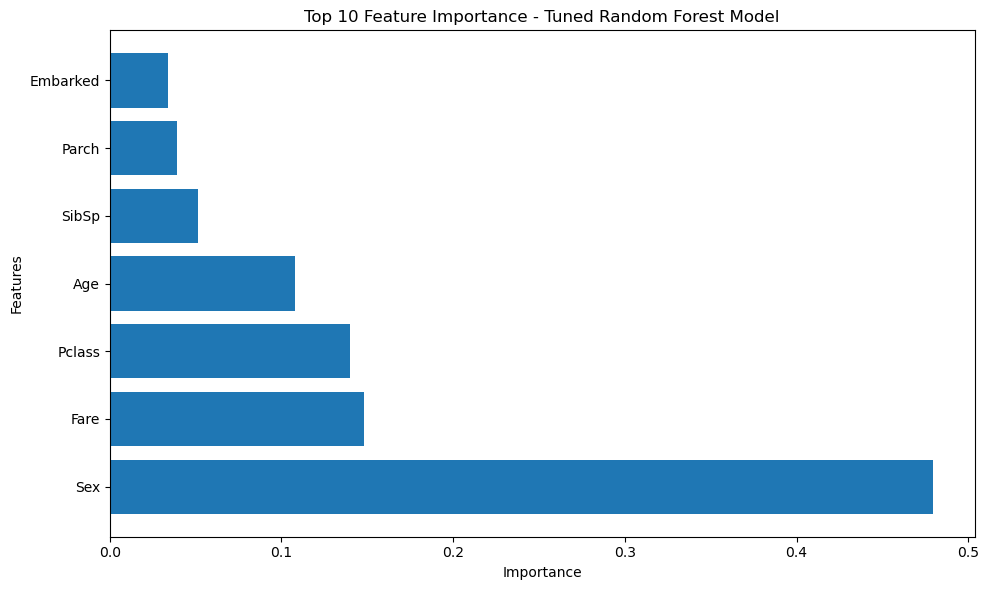

In [86]:
# Get feature importance from Gradient Boosting model
feature_importance = best_model.feature_importances_  #use dtune model
feature_names = X_train.columns

# Create a DataFrame for easier sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(10)  # Top 10 features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance - Tuned Random Forest Model')
plt.tight_layout()
plt.show()

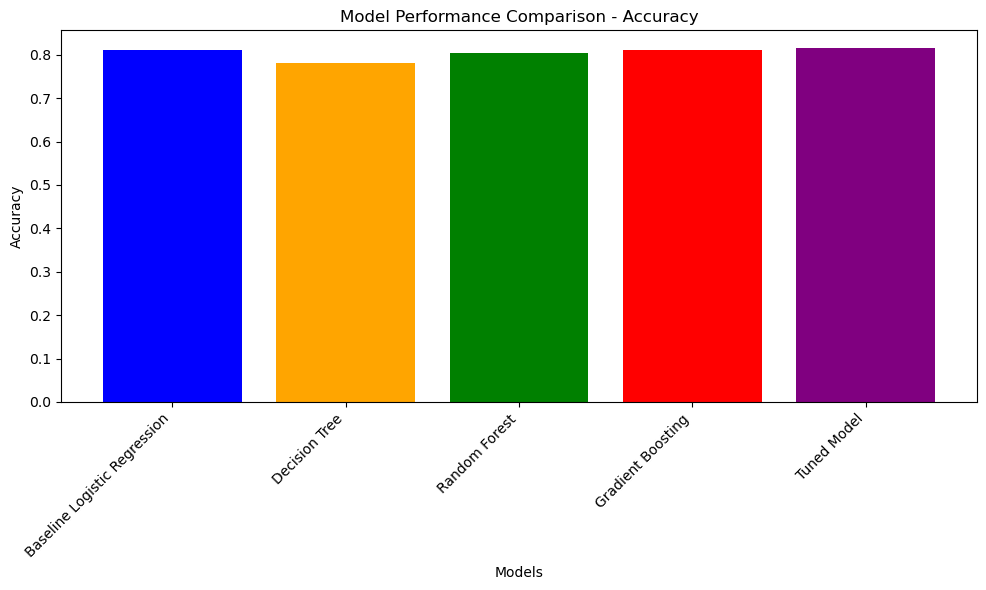

In [87]:
models = list(titanic_results.keys())
accuracy_scores = [titanic_results[model]['Accuracy'] for model in models]
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy_scores, color=['blue', 'orange', 'green', 'red', 'purple'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison - Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

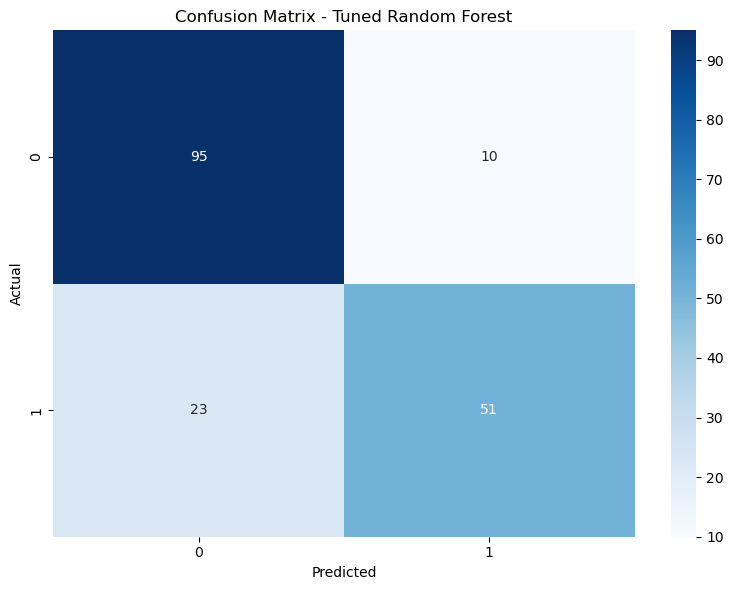

In [88]:
# Confusion Matrix for Tuned Model
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.tight_layout()
plt.show()

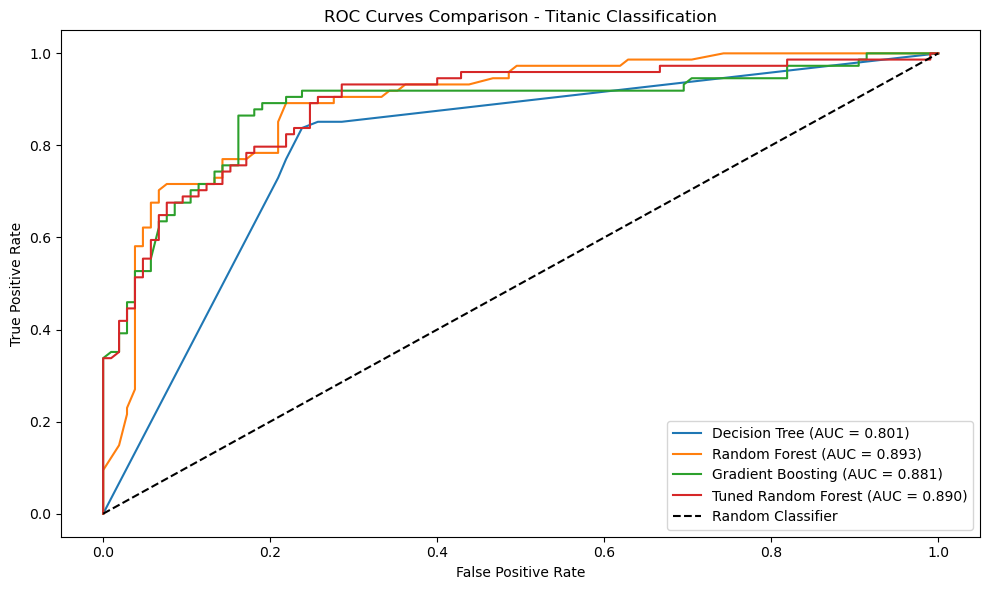

In [89]:
# Train models 
models_to_plot = {
    'Decision Tree': model,  #  Decision Tree variable name
    'Random Forest': forest,  #  Random Forest variable name
    'Gradient Boosting': gradient,  #  Gradient Boosting variable name
    'Tuned Random Forest': best_model  #  tuned model
}
plt.figure(figsize=(10, 6))

for model_name, model in models_to_plot.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison - Titanic Classification')
plt.legend()
plt.tight_layout()
plt.show()

# WEEK 6: FEATURE ENGINEERING AND MODEL OPTIMIZATION


## FEATURE ENGINEERING

In [90]:
print("\n"  + "="*50)
print("Feature Enginnering")
print("="*50)



Feature Enginnering


In [91]:
# Extract title from Name
Titanic['Title'] = Titanic['Name'].str.extract('([A-Za-z]+)\.', expand=False)
Titanic['Title'] = Titanic['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Capt', 'Jonkheer', 'Dona'], 'Rare')
print(" Created Title feature")

# Family size
Titanic['FamilySize'] = Titanic['SibSp'] + Titanic['Parch'] + 1
print(" Created FamilySize feature")

# Age groups
Titanic['AgeGroup'] = pd.cut(Titanic['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
print(" Created AgeGroup feature")

# Is alone
Titanic['IsAlone'] = (Titanic['FamilySize'] == 1).astype(int)
print(" Created IsAlone feature")

# Fare per person
Titanic['FarePerPerson'] = Titanic['Fare'] / Titanic['FamilySize']
print(" Created FarePerPerson feature")

 Created Title feature
 Created FamilySize feature
 Created AgeGroup feature
 Created IsAlone feature
 Created FarePerPerson feature


In [92]:

# Fill missing values
Titanic['Age'].fillna(Titanic['Age'].median(), inplace=True)
Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0], inplace=True)
Titanic['Fare'].fillna(Titanic['Fare'].median(), inplace=True)
Titanic['FarePerPerson'].fillna(Titanic['FarePerPerson'].median(), inplace=True)
print(" Filled missing values")

# Label Encoding for categorical variables
le_sex = LabelEncoder()
Titanic['Sex'] = le_sex.fit_transform(Titanic['Sex'])  # male=1, female=0

le_embarked = LabelEncoder()
Titanic['Embarked'] = le_embarked.fit_transform(Titanic['Embarked'])

le_title = LabelEncoder()
Titanic['Title'] = le_title.fit_transform(Titanic['Title'])

le_agegroup = LabelEncoder()
Titanic['AgeGroup'] = le_agegroup.fit_transform(Titanic['AgeGroup'])
print(" Label encoded categorical variables")

# Select features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
            'Embarked', 'Title', 'FamilySize', 'AgeGroup', 'IsAlone', 'FarePerPerson']
X = Titanic[features]
y = Titanic['Survived']

# Standardization/Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
print(" Scaled features")



 Filled missing values
 Label encoded categorical variables
 Scaled features


In [93]:
# ====================
# 4. FEATURE SELECTION
# ====================
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)

# Correlation Analysis - Add target to X_scaled temporarily
X_scaled_with_target = X_scaled.copy()
X_scaled_with_target['Survived'] = y.values
correlation = X_scaled_with_target.corr()['Survived'].sort_values(ascending=False)
print("\nCorrelation with Survived:\n", correlation)

# Feature Importance using Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled, y)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:\n", feature_importance)

# Select top features (you can adjust threshold)
top_features = feature_importance.head(8)['Feature'].tolist()
print(f"\n Selected top {len(top_features)} features: {top_features}")

X_selected = X_scaled[top_features]


FEATURE SELECTION

Correlation with Survived:
 Survived         1.000000
Fare             0.257307
FarePerPerson    0.221600
Parch            0.081629
AgeGroup         0.039960
FamilySize       0.016639
SibSp           -0.035322
Age             -0.064910
Embarked        -0.167675
IsAlone         -0.203367
Title           -0.221632
Pclass          -0.338481
Sex             -0.543351
Name: Survived, dtype: float64

Feature Importance:
           Feature  Importance
1             Sex    0.203733
2             Age    0.176435
5            Fare    0.157461
11  FarePerPerson    0.153166
7           Title    0.106043
0          Pclass    0.058527
8      FamilySize    0.046410
9        AgeGroup    0.025336
6        Embarked    0.024172
3           SibSp    0.023040
4           Parch    0.015775
10        IsAlone    0.009904

 Selected top 8 features: ['Sex', 'Age', 'Fare', 'FarePerPerson', 'Title', 'Pclass', 'FamilySize', 'AgeGroup']


In [94]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")



Train size: 712, Test size: 179


In [95]:
# . BASELINE MODEL (BEFORE OPTIMIZATION)

print("\n" + "="*50)
print("BASELINE MODEL PERFORMANCE")
print("="*50)

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
y_pred_baseline = lr_baseline.predict(X_test)

print("Logistic Regression (Baseline):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_baseline):.4f}")

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline),
    'Recall': recall_score(y_test, y_pred_baseline),
    'F1': f1_score(y_test, y_pred_baseline),
    'ROC-AUC': roc_auc_score(y_test, y_pred_baseline)
}


BASELINE MODEL PERFORMANCE
Logistic Regression (Baseline):
  Accuracy:  0.8101
  Precision: 0.8030
  Recall:    0.7162
  F1 Score:  0.7571
  ROC-AUC:   0.7962


In [96]:
#  HYPERPARAMETER TUNING (OPTIMIZATION)
# ====================
print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Random Forest tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Running GridSearchCV for Random Forest...")
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f" Best parameters: {grid_rf.best_params_}")
print(f" Best CV score: {grid_rf.best_score_:.4f}")


HYPERPARAMETER TUNING
Running GridSearchCV for Random Forest...
 Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
 Best CV score: 0.8643


In [97]:
#  OPTIMIZED MODEL PERFORMANCE
# ====================
print("\n" + "="*50)
print("OPTIMIZED MODEL PERFORMANCE")
print("="*50)

rf_optimized = grid_rf.best_estimator_
y_pred_optimized = rf_optimized.predict(X_test)

print("Random Forest (Optimized):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimized):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimized):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_optimized):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_optimized):.4f}")

optimized_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_optimized),
    'Precision': precision_score(y_test, y_pred_optimized),
    'Recall': recall_score(y_test, y_pred_optimized),
    'F1': f1_score(y_test, y_pred_optimized),
    'ROC-AUC': roc_auc_score(y_test, y_pred_optimized)
}


OPTIMIZED MODEL PERFORMANCE
Random Forest (Optimized):
  Accuracy:  0.7989
  Precision: 0.7879
  Recall:    0.7027
  F1 Score:  0.7429
  ROC-AUC:   0.7847



GENERATING VISUALIZATIONS
 Saved visualization as 'titanic_optimization_results.png'


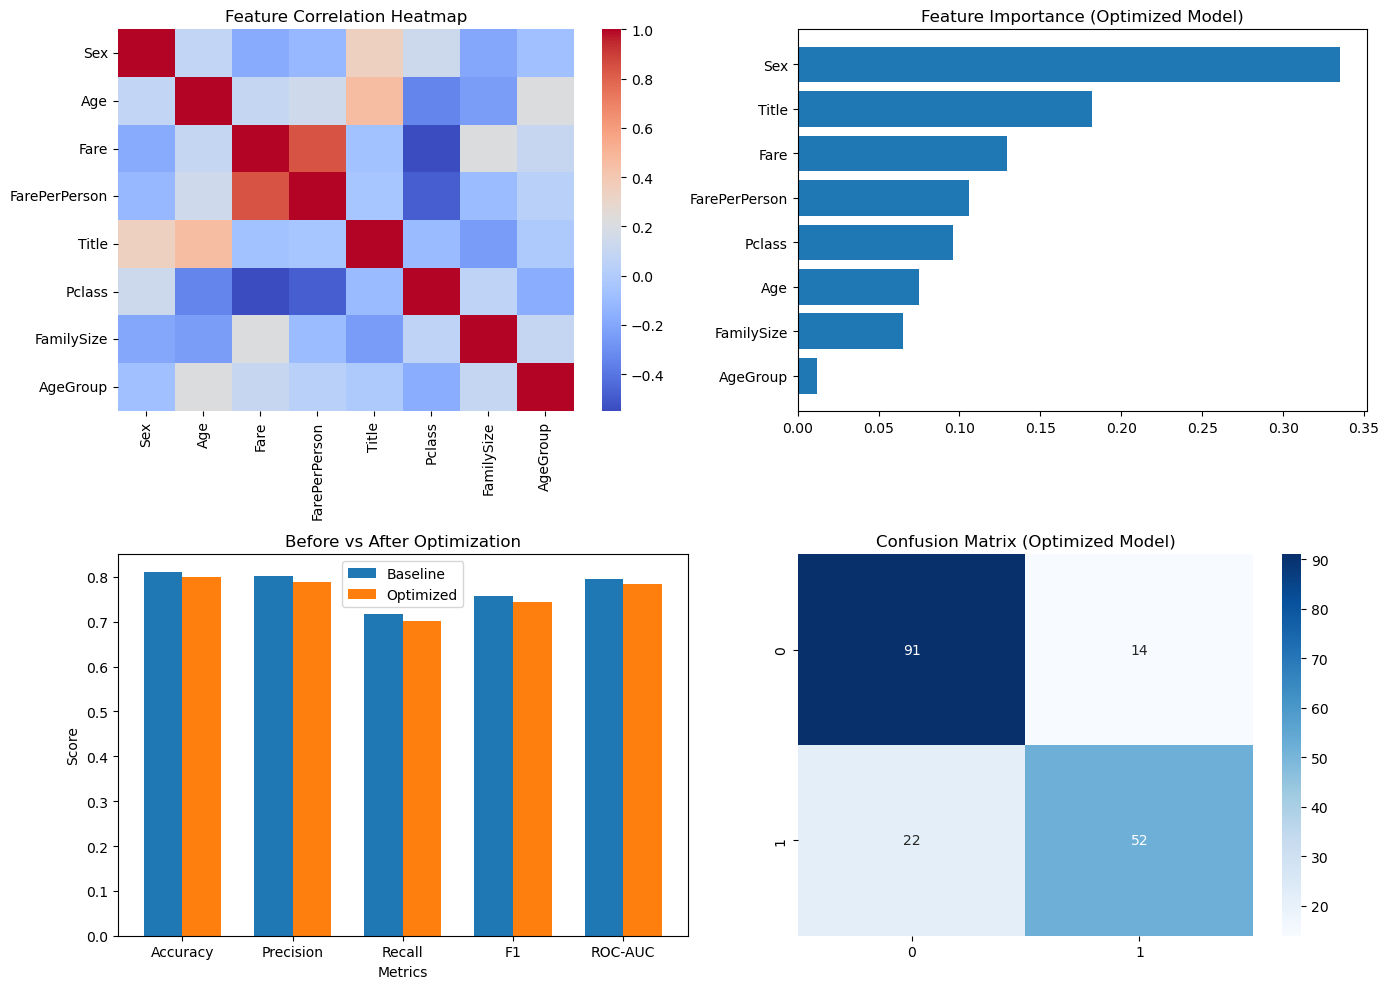

In [98]:
#  VISUALIZATIONS
# ====================
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correlation heatmap
sns.heatmap(X_selected.corr(), annot=False, cmap='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Feature Correlation Heatmap')

# 2. Feature importance
feature_importance_selected = pd.DataFrame({
    'Feature': top_features,
    'Importance': rf_optimized.feature_importances_
}).sort_values('Importance', ascending=True)
axes[0, 1].barh(feature_importance_selected['Feature'], feature_importance_selected['Importance'])
axes[0, 1].set_title('Feature Importance (Optimized Model)')

# 3. Performance comparison
metrics_names = list(baseline_metrics.keys())
baseline_values = list(baseline_metrics.values())
optimized_values = list(optimized_metrics.values())

x = np.arange(len(metrics_names))
width = 0.35
axes[1, 0].bar(x - width/2, baseline_values, width, label='Baseline')
axes[1, 0].bar(x + width/2, optimized_values, width, label='Optimized')
axes[1, 0].set_xlabel('Metrics')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Before vs After Optimization')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_names)
axes[1, 0].legend()

# 4. Confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Confusion Matrix (Optimized Model)')

plt.tight_layout()
plt.savefig('titanic_optimization_results.png', dpi=300, bbox_inches='tight')
print(" Saved visualization as 'titanic_optimization_results.png'")
plt.show()

In [99]:
#  SUMMARY REPORT
# ====================
print("\n" + "="*50)
print("OPTIMIZATION SUMMARY")
print("="*50)
print(f"\nFeatures Engineering: 5 new features created")
print(f"Features Selected: {len(top_features)} out of {len(features)}")
print(f"\nBefore Optimization (Logistic Regression):")
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nAfter Optimization (Random Forest):")
for metric, value in optimized_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nImprovement:")
for metric in baseline_metrics.keys():
    improvement = optimized_metrics[metric] - baseline_metrics[metric]
    pct_improvement = (improvement / baseline_metrics[metric]) * 100 if baseline_metrics[metric] != 0 else 0
    print(f"  {metric}: +{improvement:.4f} ({pct_improvement:.2f}%)")


OPTIMIZATION SUMMARY

Features Engineering: 5 new features created
Features Selected: 8 out of 12

Before Optimization (Logistic Regression):
  Accuracy: 0.8101
  Precision: 0.8030
  Recall: 0.7162
  F1: 0.7571
  ROC-AUC: 0.7962

After Optimization (Random Forest):
  Accuracy: 0.7989
  Precision: 0.7879
  Recall: 0.7027
  F1: 0.7429
  ROC-AUC: 0.7847

Improvement:
  Accuracy: +-0.0112 (-1.38%)
  Precision: +-0.0152 (-1.89%)
  Recall: +-0.0135 (-1.89%)
  F1: +-0.0143 (-1.89%)
  ROC-AUC: +-0.0115 (-1.45%)


# Week 7: Model Deployment & Real-World Application
## Overview
- Building a machine learning model is only one part of a data science project. To create real-world value, the model must be deployed so that users or applications can interact with it and receive predictions.

## Objective
- To deploy a machine learning model and make it capable of generating predictions through an API or simple web application.

### SAVING THE MODEL USING JOBLIB

In [101]:
joblib.dump(model, "titanic_prediction") #persisting the model

print("Model Saved Successfully")

Model Saved Successfully


In [102]:
model = joblib.load("titanic_prediction")

In [103]:
import os
print(os.getcwd())  # Shows you where files are being saved
os.listdir()        # Lists all files in that directory

C:\Users\User PC\Data Science\AnalystLab_Africa_Intern


['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'desktop.ini',
 'Housing.csv',
 'Housing_wk1_.ipynb',
 'PDF_REPORT.ipynb',
 'README.md',
 'Titanic wk1.ipynb',
 'Titanic-Dataset.csv',
 'titanic_optimization_results.png',
 'titanic_prediction']

In [107]:
print(Titanic["Sex"].value_counts())

Sex
1    577
0    314
Name: count, dtype: int64
